Name: Prayash Gupta PRN: 23070521110

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### 1. Data Preprocessing

First, we'll load the dataset and perform an initial exploration to understand its structure and identify any immediate issues like missing values or incorrect data types.

In [ ]:
df = pd.read_csv('/content/telecom_churn.csv')
display(df.head())

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


None

In [ ]:
display(df.describe())

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


### 2. Prepare Data for Model Training

We need to separate the features (X) from the target variable (y), scale the features to a standard range, and then split the dataset into training and testing sets.

In [ ]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2666, 10)
X_test shape: (667, 10)
y_train shape: (2666,)
y_test shape: (667,)


### 3. Build and Train the Deep Neural Network Model

We will now construct a deep neural network using TensorFlow/Keras. The model will consist of several dense layers with ReLU activation, followed by a sigmoid output layer for binary classification. We will compile the model using the Adam optimizer and binary cross-entropy loss, and then train it on our preprocessed training data.

In [ ]:
# Define the model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

print("Model training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Model training complete.


### 4. Evaluate Model Performance

After training, we will evaluate the model's performance using the test dataset. This involves predicting churn on the test set, calculating the overall accuracy, and generating a confusion matrix to get a detailed view of true positives, true negatives, false positives, and false negatives.

In [ ]:
# Predict on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test Accuracy: 0.9295

Confusion Matrix:
[[562   4]
 [ 43  58]]


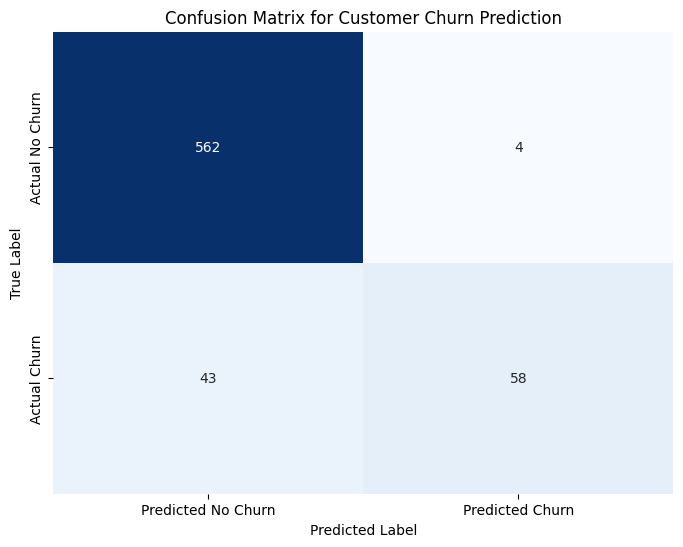

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Customer Churn Prediction')
plt.show()

### 5. Analyze Feature Importance (using Correlation as a proxy)

To understand which features are most associated with churn, we can examine the correlation of each feature with the 'Churn' target variable. While not a direct measure of importance for the neural network, it provides valuable insights into the underlying data relationships.

/tmp/ipykernel_1978/3924121189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_churn.index, y=correlation_with_churn.values, palette='viridis')


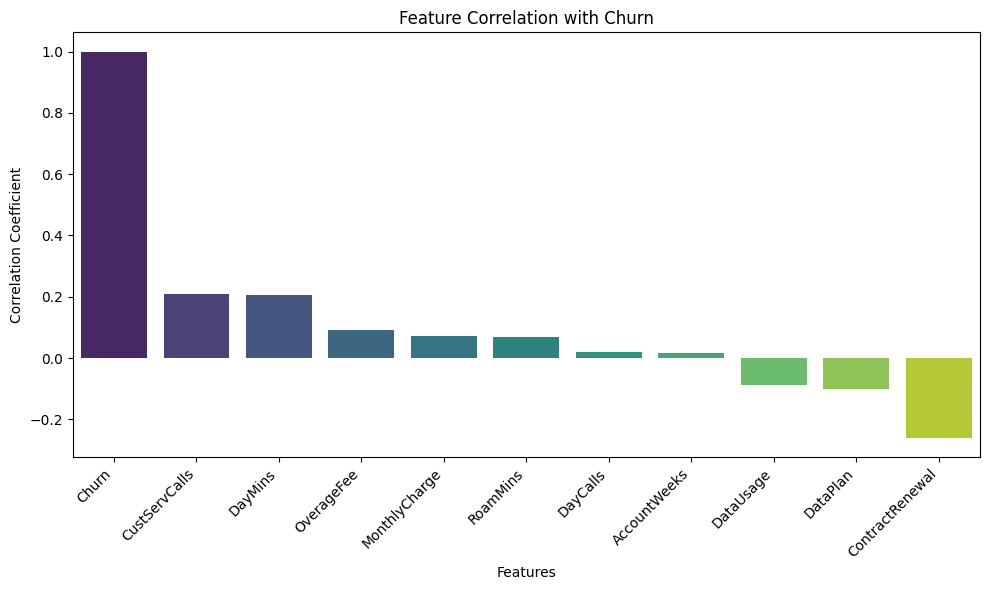

In [ ]:
correlation_with_churn = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_churn.index, y=correlation_with_churn.values, palette='viridis')
plt.title('Feature Correlation with Churn')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6. Build and Compare a New Model with 3 Hidden Layers

Now, let's create a new Deep Neural Network with 3 hidden layers and compare its performance (accuracy) to the model we previously built (which had 2 hidden layers).

In [ ]:
# Define the new model with 3 hidden layers
model_3_layers = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the new model
model_3_layers.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model_3_layers.summary()

# Train the new model
history_3_layers = model_3_layers.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

print("Model with 3 layers training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

Model with 3 layers training complete.


In [ ]:
# Evaluate the new model
y_pred_prob_3_layers = model_3_layers.predict(X_test)
y_pred_3_layers = (y_pred_prob_3_layers > 0.5).astype(int)

accuracy_3_layers = accuracy_score(y_test, y_pred_3_layers)
print(f"Test Accuracy (3-layer model): {accuracy_3_layers:.4f}")

# Retrieve accuracy of the first model (assuming 'accuracy' variable still holds it)
print(f"Test Accuracy (2-layer model): {accuracy:.4f}")

print("\nComparison:")
if accuracy_3_layers > accuracy:
    print(f"The 3-layer model performed better with an accuracy of {accuracy_3_layers:.4f} compared to the 2-layer model's {accuracy:.4f}.")
elif accuracy_3_layers < accuracy:
    print(f"The 2-layer model performed better with an accuracy of {accuracy:.4f} compared to the 3-layer model's {accuracy_3_layers:.4f}.")
else:
    print(f"Both models achieved similar accuracy of {accuracy:.4f}.")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test Accuracy (3-layer model): 0.9310
Test Accuracy (2-layer model): 0.9295

Comparison:
The 3-layer model performed better with an accuracy of 0.9310 compared to the 2-layer model's 0.9295.


### 7. Build and Compare a New Model with 5 Hidden Layers

Let's build another Deep Neural Network, this time with 5 hidden layers, and compare its performance to the previous 2-layer and 3-layer models.

In [ ]:
# Define the new model with 5 hidden layers
model_5_layers = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the new model
model_5_layers.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model_5_layers.summary()

# Train the new model
history_5_layers = model_5_layers.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=0)

print("Model with 5 layers training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,593 (182.00 KB)

 Trainable params: 46,593 (182.00 KB)

 Non-trainable params: 0 (0.00 B)

Model with 5 layers training complete.


In [ ]:
# NEW MODEL WITH BATCH SIZE HALVED AND EPOCHS DOUBLED

# Evaluate the new model
y_pred_prob_5_layers = model_5_layers.predict(X_test)
y_pred_5_layers = (y_pred_prob_5_layers > 0.5).astype(int)

accuracy_5_layers = accuracy_score(y_test, y_pred_5_layers)
print(f"Test Accuracy (5-layer model): {accuracy_5_layers:.4f}")

# Print accuracies of all models for comparison
print(f"\nTest Accuracy (2-layer model): {accuracy:.4f}")
print(f"Test Accuracy (3-layer model): {accuracy_3_layers:.4f}")
print(f"Test Accuracy (5-layer model): {accuracy_5_layers:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Test Accuracy (5-layer model): 0.9250

Test Accuracy (2-layer model): 0.9295
Test Accuracy (3-layer model): 0.9310
Test Accuracy (5-layer model): 0.9250


In [ ]:
# Evaluate the new model
y_pred_prob_5_layers = model_5_layers.predict(X_test)
y_pred_5_layers = (y_pred_prob_5_layers > 0.5).astype(int)

accuracy_5_layers = accuracy_score(y_test, y_pred_5_layers)
print(f"Test Accuracy (5-layer model): {accuracy_5_layers:.4f}")

# Print accuracies of all models for comparison
print(f"\nTest Accuracy (2-layer model): {accuracy:.4f}")
print(f"Test Accuracy (3-layer model): {accuracy_3_layers:.4f}")
print(f"Test Accuracy (5-layer model): {accuracy_5_layers:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test Accuracy (5-layer model): 0.9310

Test Accuracy (2-layer model): 0.9295
Test Accuracy (3-layer model): 0.9310
Test Accuracy (5-layer model): 0.9310


### 8. Visualize Model Accuracy Comparison

Now, let's visualize the test accuracies of all three models (2-layer, 3-layer, and 5-layer) to easily compare their performance.

/tmp/ipykernel_1978/1838995603.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')


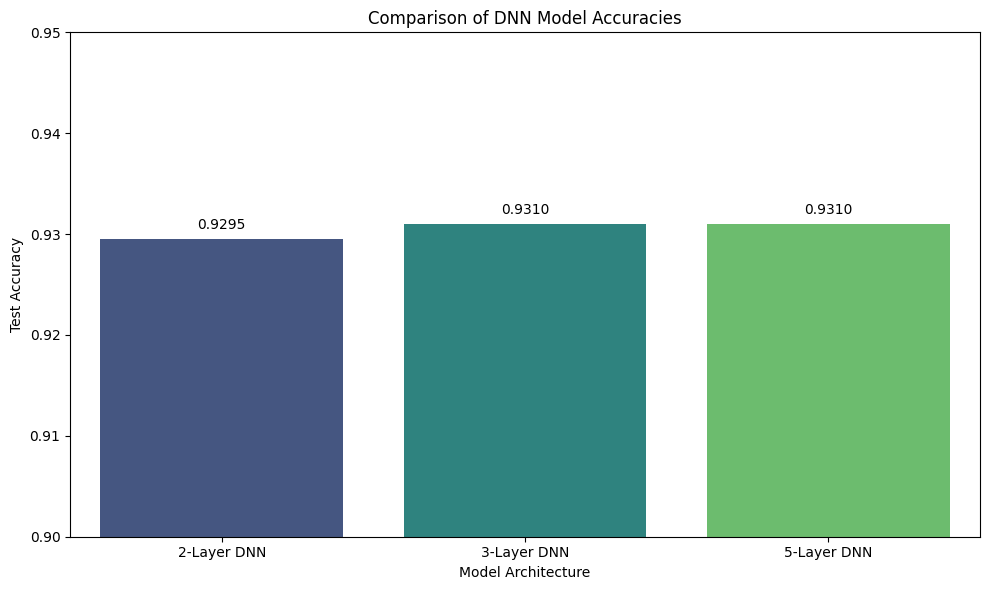

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting
model_accuracies = pd.DataFrame({
    'Model': ['2-Layer DNN', '3-Layer DNN', '5-Layer DNN'],
    'Accuracy': [accuracy, accuracy_3_layers, accuracy_5_layers]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')
plt.ylim(0.90, 0.95) # Set y-axis limits to better highlight differences
plt.title('Comparison of DNN Model Accuracies')
plt.xlabel('Model Architecture')
plt.ylabel('Test Accuracy')

# Add accuracy values on top of the bars
for index, row in model_accuracies.iterrows():
    plt.text(index, row.Accuracy + 0.001, f'{row.Accuracy:.4f}', color='black', ha="center")

plt.tight_layout()
plt.show()